In [1]:
# %% [markdown]
# # 基于深度卷积神经网络的手语识别
# ### Sign Language MNIST 数据集（A-Y，24类）
# 
# **项目结构：**
# 1. 数据加载与预处理（标签重映射、归一化、验证集划分）
# 2. 构建两种CNN模型（基线CNN 与 增强VGG风格CNN）
# 3. 训练、测试与评估（学习率调优、训练曲线、混淆矩阵、分类报告）
# 4. 样本预测可视化
# 
# **文件要求：**  
# - `sign_mnist_train.csv` 和 `sign_mnist_test.csv` 与本 notebook 在同一目录下  
# - 若训练集尚未提供，本代码会先加载测试集并显示形状，训练部分需等待训练集后再运行
# 必须在导入 TensorFlow 之前设置！

# %%
# ==================== 导入库 ====================
import os

# 必须在导入 TensorFlow 之前设置环境变量！
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'
os.environ['TF_ENABLE_ONEDNN_OPTS'] = '0'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping
import time
import warnings
warnings.filterwarnings('ignore')

# 固定随机种子确保结果可复现
np.random.seed(42)
tf.random.set_seed(42)
# %%

2026-05-06 15:55:49.811480: E tensorflow/stream_executor/cuda/cuda_blas.cc:2981] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [2]:
# %%
# ==================== 1. 数据加载 ====================
print("=" * 50)
print("正在加载 Sign Language MNIST 数据集...")
print("=" * 50)

train_path = 'sign_mnist_train.csv'
test_path = 'sign_mnist_test.csv'

train_exists = os.path.exists(train_path)
test_exists = os.path.exists(test_path)

if test_exists:
    test_df = pd.read_csv(test_path)
    print(f"\n测试集加载成功！形状: {test_df.shape}")
else:
    print(f"\n警告：未找到测试集文件 {test_path}")
    test_df = None

if train_exists:
    train_df = pd.read_csv(train_path)
    print(f"训练集加载成功！形状: {train_df.shape}")
else:
    print(f"警告：未找到训练集文件 {train_path}")
    train_df = None
    print("请先提供训练集文件后再运行后续训练代码。")

# %%

正在加载 Sign Language MNIST 数据集...

测试集加载成功！形状: (7172, 785)
训练集加载成功！形状: (27455, 785)



原始标签范围: [ 0  1  2  3  4  5  6  7  8 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24]
重映射后标签范围: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23] (0-23)

数据形状:
  训练集: (24709, 28, 28, 1), 标签: (24709, 24)
  验证集: (2746, 28, 28, 1), 标签: (2746, 24)
  测试集: (7172, 28, 28, 1), 标签: (7172, 24)


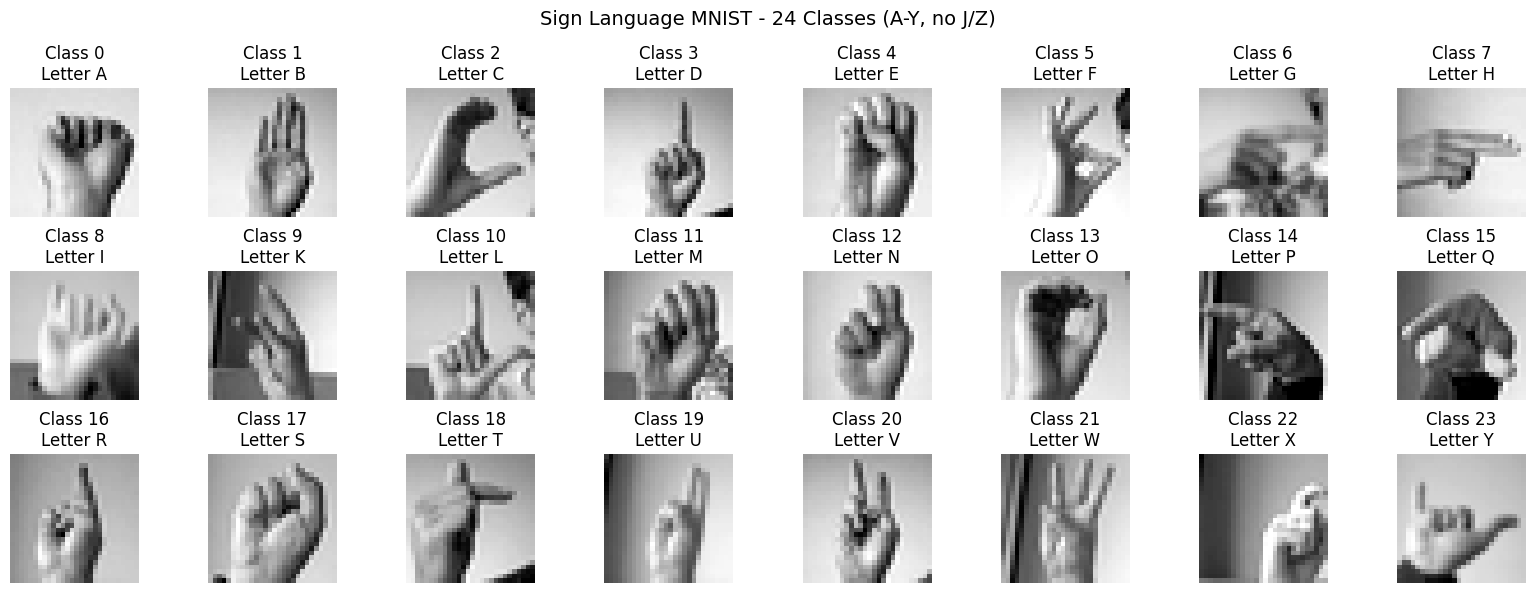

In [3]:
# ==================== 2. 数据预处理 ====================
if train_df is not None:
    y_train_full = train_df['label'].values
    X_train_full = train_df.drop('label', axis=1).values
    
    if test_df is not None:
        y_test = test_df['label'].values
        X_test = test_df.drop('label', axis=1).values
    else:
        X_train_full, X_test, y_train_full, y_test = train_test_split(
            X_train_full, y_train_full, test_size=0.1, random_state=42, stratify=y_train_full
        )
    
    print(f"\n原始标签范围: {np.unique(y_train_full)}")
    unique_labels = sorted(np.unique(y_train_full))
    label_map = {old: new for new, old in enumerate(unique_labels)}
    reverse_label_map = {new: old for old, new in label_map.items()}
    
    y_train_full = np.array([label_map[l] for l in y_train_full])
    y_test = np.array([label_map[l] for l in y_test])
    
    print(f"重映射后标签范围: {np.unique(y_train_full)} (0-23)")
    
    X_train_full = X_train_full.astype('float32') / 255.0
    X_test = X_test.astype('float32') / 255.0
    
    X_train_full = X_train_full.reshape(-1, 28, 28, 1)
    X_test = X_test.reshape(-1, 28, 28, 1)
    
    X_train, X_val, y_train, y_val = train_test_split(
        X_train_full, y_train_full, test_size=0.1, random_state=42, stratify=y_train_full
    )
    
    num_classes = 24
    y_train_cat = to_categorical(y_train, num_classes)
    y_val_cat = to_categorical(y_val, num_classes)
    y_test_cat = to_categorical(y_test, num_classes)
    
    print(f"\n数据形状:")
    print(f"  训练集: {X_train.shape}, 标签: {y_train_cat.shape}")
    print(f"  验证集: {X_val.shape}, 标签: {y_val_cat.shape}")
    print(f"  测试集: {X_test.shape}, 标签: {y_test_cat.shape}")
    
    fig, axes = plt.subplots(3, 8, figsize=(16, 6))
    axes = axes.flatten()
    for i in range(24):
        idx = np.where(y_train == i)[0][0]
        axes[i].imshow(X_train[idx].reshape(28, 28), cmap='gray')
        letter = chr(65 + reverse_label_map[i])
        axes[i].set_title(f"Class {i}\nLetter {letter}")
        axes[i].axis('off')
    plt.suptitle("Sign Language MNIST - 24 Classes (A-Y, no J/Z)", fontsize=14)
    plt.tight_layout()
    plt.show()

# %%

In [4]:
# ==================== 3. 构建基线 CNN ====================
def build_baseline_cnn(input_shape=(28, 28, 1), num_classes=24):
    model = models.Sequential([
        layers.Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=input_shape),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)),
        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(num_classes, activation='softmax')
    ])
    return model


In [5]:
# %%
# ==================== 4. 构建增强 VGG 风格 CNN ====================
def build_vgg_style_cnn(input_shape=(28, 28, 1), num_classes=24):
    model = models.Sequential([
        layers.Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=input_shape),
        layers.BatchNormalization(),
        layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),
        
        layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),
        
        layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),
        
        layers.Flatten(),
        layers.Dense(256, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.5),
        layers.Dense(128, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.5),
        layers.Dense(num_classes, activation='softmax')
    ])
    return model

# %%

In [6]:
# ==================== 5. 训练与评估函数 ====================
def train_and_evaluate(model, model_name, X_train, y_train, X_val, y_val, X_test, y_test, 
                       epochs=30, batch_size=64):
    print(f"\n{'='*50}")
    print(f"训练模型: {model_name}")
    print(f"{'='*50}")
    
    model.compile(
        optimizer=optimizers.Adam(learning_rate=0.001),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    model.summary()
    
    lr_reducer = ReduceLROnPlateau(
        monitor='val_loss', factor=0.5, patience=3, min_lr=1e-7, verbose=1
    )
    early_stop = EarlyStopping(
        monitor='val_accuracy', patience=10, restore_best_weights=True, verbose=1
    )
    
    start_time = time.time()
    history = model.fit(
        X_train, y_train,
        batch_size=batch_size,
        epochs=epochs,
        validation_data=(X_val, y_val),
        callbacks=[lr_reducer, early_stop],
        verbose=1
    )
    train_time = time.time() - start_time
    
    test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
    print(f"\n测试集准确率: {test_acc:.4f}")
    print(f"训练耗时: {train_time:.2f} 秒")
    
    return history, test_acc, train_time


In [7]:
# ==================== 6. 可视化函数 ====================
def plot_training_history(history, model_name):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    axes[0].plot(history.history['accuracy'], label='Train', linewidth=2)
    axes[0].plot(history.history['val_accuracy'], label='Val', linewidth=2)
    axes[0].set_title(f'{model_name} - Accuracy')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Accuracy')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    
    axes[1].plot(history.history['loss'], label='Train', linewidth=2)
    axes[1].plot(history.history['val_loss'], label='Val', linewidth=2)
    axes[1].set_title(f'{model_name} - Loss')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Loss')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

def plot_confusion_matrix(y_true, y_pred, model_name, reverse_label_map):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(14, 12))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
    labels = [chr(65 + reverse_label_map[i]) for i in range(24)]
    plt.xticks(np.arange(24) + 0.5, labels, rotation=0)
    plt.yticks(np.arange(24) + 0.5, labels, rotation=0)
    plt.title(f'{model_name} - Confusion Matrix', fontsize=14)
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.tight_layout()
    plt.show()

def visualize_predictions(model, X_test, y_test, reverse_label_map, num_samples=16):
    y_pred = model.predict(X_test, verbose=0)
    y_pred_classes = np.argmax(y_pred, axis=1)
    y_true_classes = np.argmax(y_test, axis=1)
    indices = np.random.choice(len(X_test), num_samples, replace=False)
    
    fig, axes = plt.subplots(4, 4, figsize=(12, 12))
    axes = axes.flatten()
    for i, idx in enumerate(indices):
        img = X_test[idx].reshape(28, 28)
        true_l = y_true_classes[idx]
        pred_l = y_pred_classes[idx]
        true_letter = chr(65 + reverse_label_map[true_l])
        pred_letter = chr(65 + reverse_label_map[pred_l])
        color = 'green' if true_l == pred_l else 'red'
        axes[i].imshow(img, cmap='gray')
        axes[i].set_title(f'True: {true_letter} | Pred: {pred_letter}', color=color)
        axes[i].axis('off')
    plt.suptitle('Sample Predictions (Green=Correct, Red=Wrong)', fontsize=14)
    plt.tight_layout()
    plt.show()

# %%


训练模型: Baseline CNN
Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 28, 28, 32)        320       
                                                                 
 max_pooling2d (MaxPooling2D  (None, 14, 14, 32)       0         
 )                                                               
                                                                 
 conv2d_1 (Conv2D)           (None, 14, 14, 64)        18496     
                                                                 
 max_pooling2d_1 (MaxPooling  (None, 7, 7, 64)         0         
 2D)                                                             
                                                                 
 flatten (Flatten)           (None, 3136)              0         
                                                                 
 dense (Dense)               (None, 

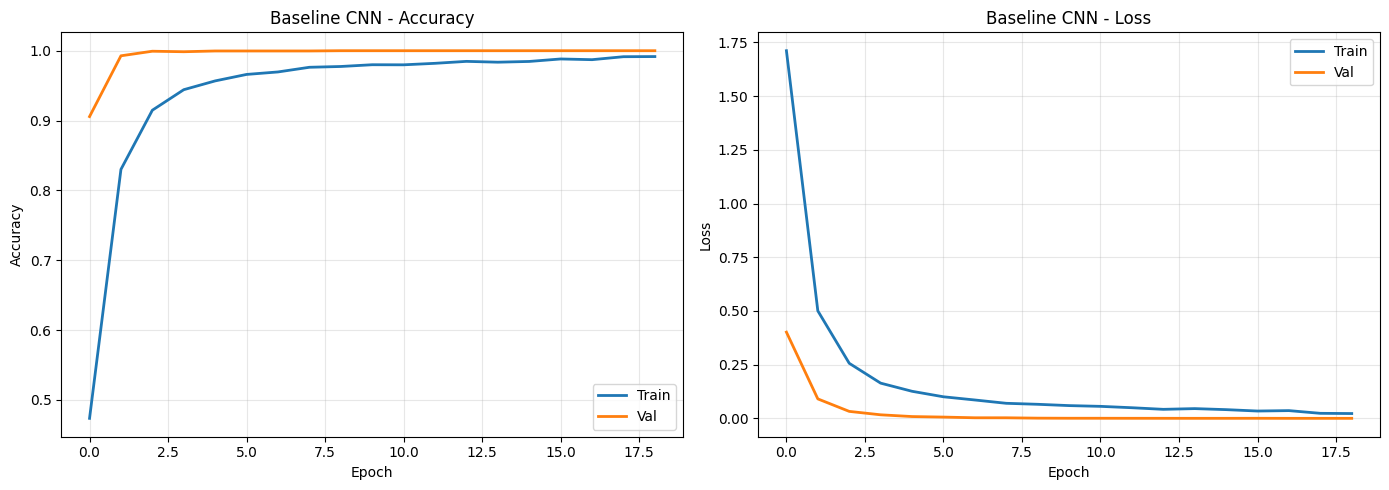


训练模型: VGG-Style CNN
Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_2 (Conv2D)           (None, 28, 28, 32)        320       
                                                                 
 batch_normalization (BatchN  (None, 28, 28, 32)       128       
 ormalization)                                                   
                                                                 
 conv2d_3 (Conv2D)           (None, 28, 28, 32)        9248      
                                                                 
 batch_normalization_1 (Batc  (None, 28, 28, 32)       128       
 hNormalization)                                                 
                                                                 
 max_pooling2d_2 (MaxPooling  (None, 14, 14, 32)       0         
 2D)                                                             
                                 

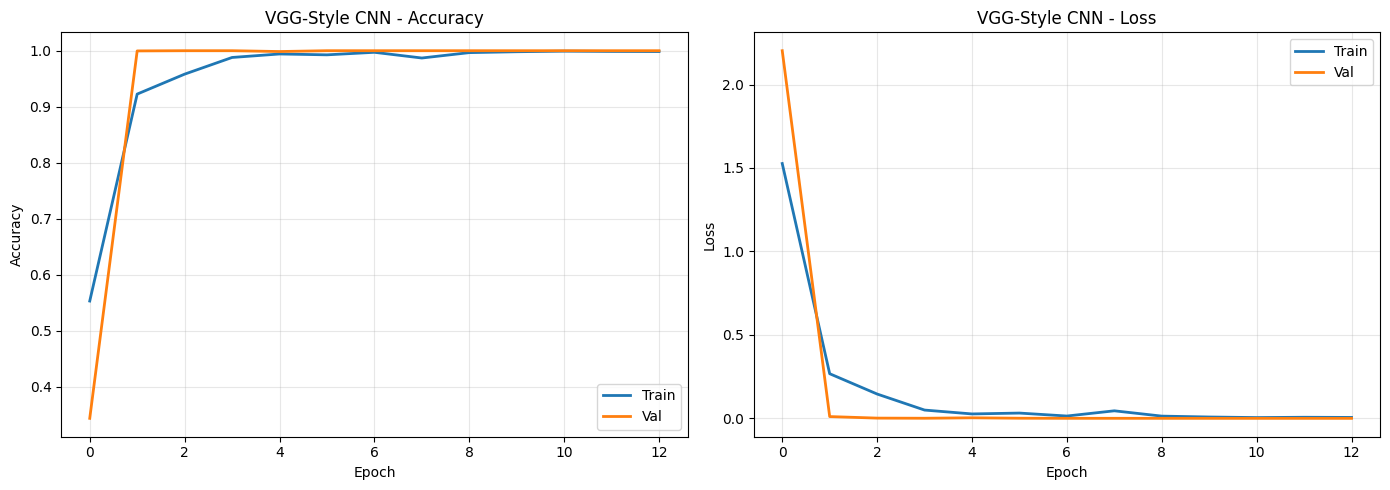


模型性能对比
Baseline CNN         | 准确率: 0.9261 | 耗时: 97.4s
VGG-Style CNN        | 准确率: 0.9784 | 耗时: 331.8s

最佳模型: VGG-Style CNN


In [8]:
# ==================== 7. 执行训练 ====================
if train_df is not None:
    results = {}
    
    baseline_model = build_baseline_cnn()
    history1, acc1, time1 = train_and_evaluate(
        baseline_model, "Baseline CNN", 
        X_train, y_train_cat, X_val, y_val_cat, X_test, y_test_cat,
        epochs=30, batch_size=64
    )
    plot_training_history(history1, "Baseline CNN")
    results['Baseline CNN'] = {'accuracy': acc1, 'time': time1, 'model': baseline_model}
    
    vgg_model = build_vgg_style_cnn()
    history2, acc2, time2 = train_and_evaluate(
        vgg_model, "VGG-Style CNN", 
        X_train, y_train_cat, X_val, y_val_cat, X_test, y_test_cat,
        epochs=30, batch_size=64
    )
    plot_training_history(history2, "VGG-Style CNN")
    results['VGG-Style CNN'] = {'accuracy': acc2, 'time': time2, 'model': vgg_model}
    
    print(f"\n{'='*50}")
    print("模型性能对比")
    print(f"{'='*50}")
    for name, res in results.items():
        print(f"{name:20s} | 准确率: {res['accuracy']:.4f} | 耗时: {res['time']:.1f}s")
    
    best_model_name = max(results, key=lambda x: results[x]['accuracy'])
    best_model = results[best_model_name]['model']
    print(f"\n最佳模型: {best_model_name}")

# %%


详细评估: VGG-Style CNN


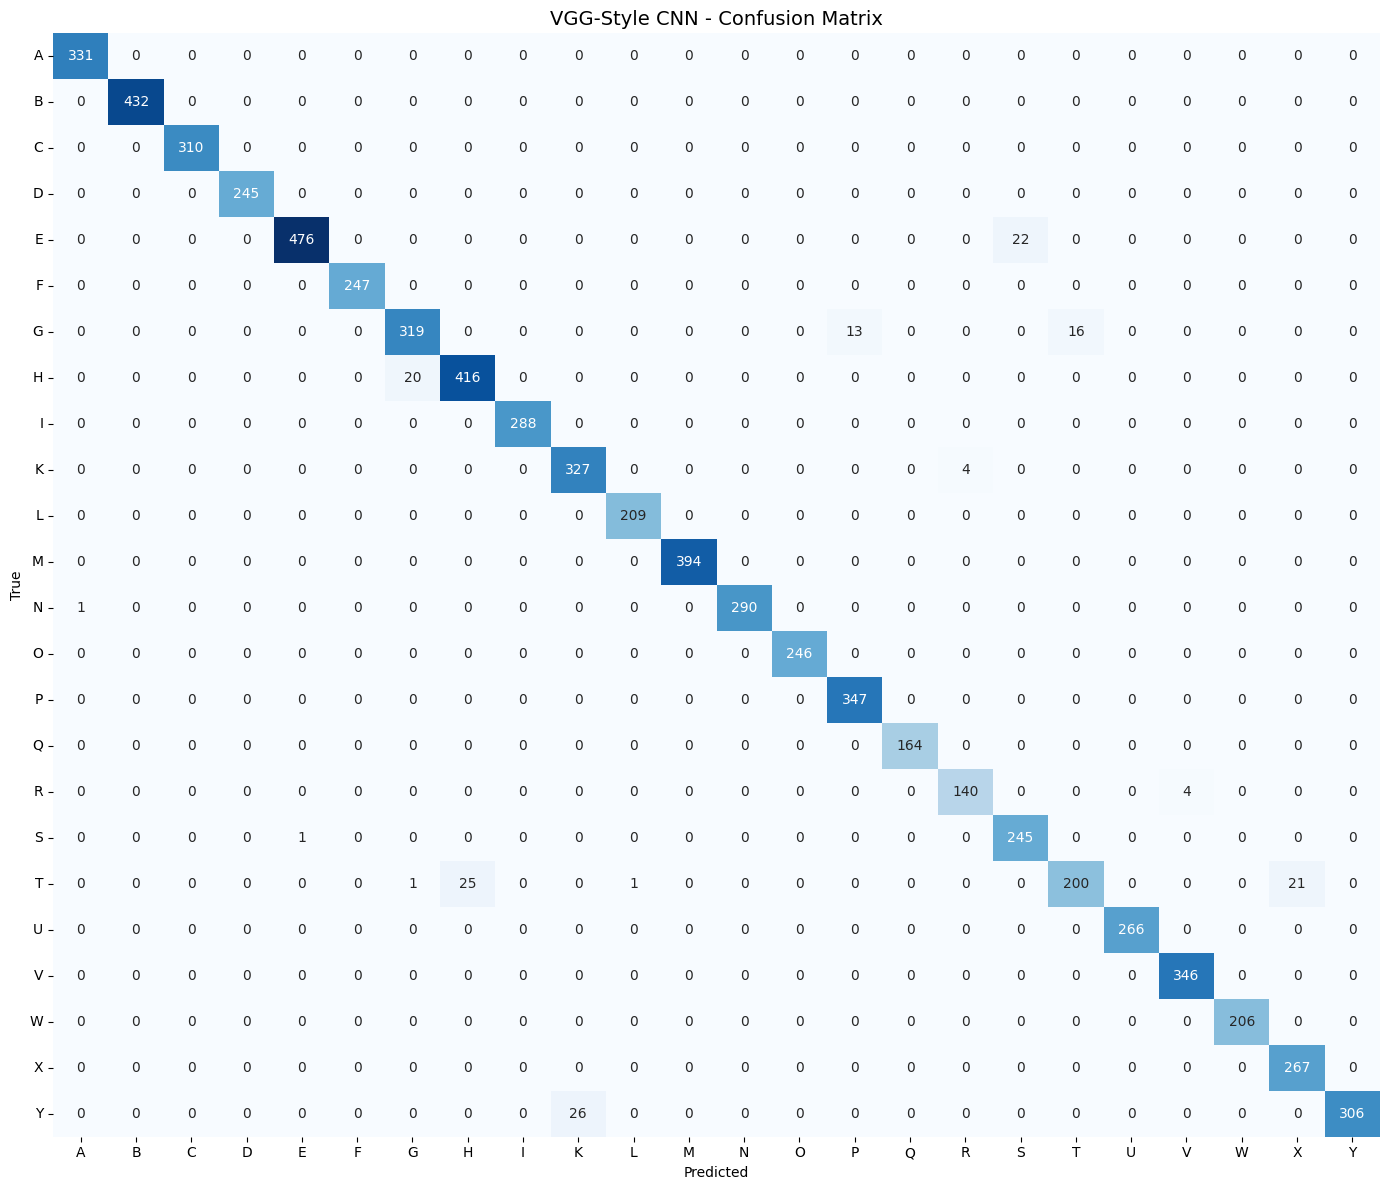


分类报告:
              precision    recall  f1-score   support

           A       1.00      1.00      1.00       331
           B       1.00      1.00      1.00       432
           C       1.00      1.00      1.00       310
           D       1.00      1.00      1.00       245
           E       1.00      0.96      0.98       498
           F       1.00      1.00      1.00       247
           G       0.94      0.92      0.93       348
           H       0.94      0.95      0.95       436
           I       1.00      1.00      1.00       288
           K       0.93      0.99      0.96       331
           L       1.00      1.00      1.00       209
           M       1.00      1.00      1.00       394
           N       1.00      1.00      1.00       291
           O       1.00      1.00      1.00       246
           P       0.96      1.00      0.98       347
           Q       1.00      1.00      1.00       164
           R       0.97      0.97      0.97       144
           S       0

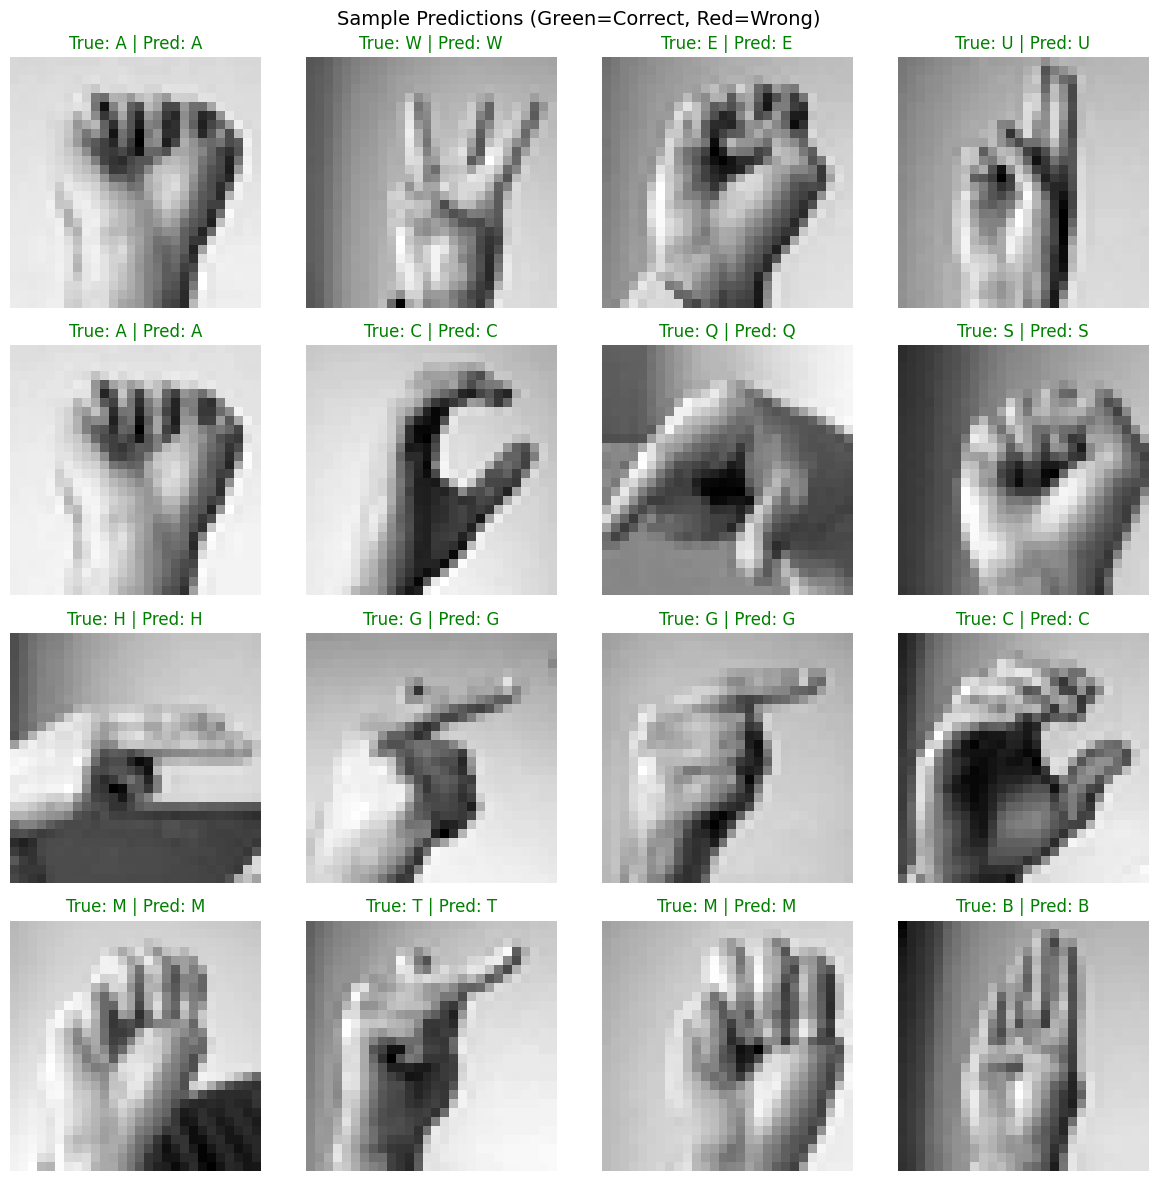


程序执行完毕！


In [9]:
# ==================== 8. 详细评估 ====================
if train_df is not None:
    print(f"\n{'='*50}")
    print(f"详细评估: {best_model_name}")
    print(f"{'='*50}")
    
    y_pred = best_model.predict(X_test, verbose=0)
    y_pred_classes = np.argmax(y_pred, axis=1)
    y_true_classes = np.argmax(y_test_cat, axis=1)
    
    plot_confusion_matrix(y_true_classes, y_pred_classes, best_model_name, reverse_label_map)
    
    target_names = [chr(65 + reverse_label_map[i]) for i in range(24)]
    print("\n分类报告:")
    print(classification_report(y_true_classes, y_pred_classes, target_names=target_names))
    
    visualize_predictions(best_model, X_test, y_test_cat, reverse_label_map, num_samples=16)

# %%
print("\n程序执行完毕！")